
PE :: $\epsilon_{cwp}$ [hr$^{-1}$]
----------------------------------------------------------------------------------------------------
DOMAIN-WIDE (all grid cells pooled; independent of lon/lat binning)
  MCS     : median=1.064, IQR=0.438–1.756, N=257335
  Non-MCS : median=0.611, IQR=0.307–0.934, N=257335
  Δmedian = 0.453
  Ratio   = 1.741

BIN-AVERAGED (equal weight per longitude bin; using bin medians)
  MCS     : median=1.098, IQR=0.706–1.352, Nbins=15
  Non-MCS : median=0.582, IQR=0.483–0.719, Nbins=15
  Δmedian = 0.516
  Ratio   = 1.886

BIN-AVERAGED (equal weight per latitude bin; using bin medians)
  MCS     : median=1.044, IQR=0.769–1.250, Nbins=12
  Non-MCS : median=0.600, IQR=0.521–0.683, Nbins=12
  Δmedian = 0.444
  Ratio   = 1.739

CIW :: $\epsilon_{i}$ [hr$^{-1}$]
----------------------------------------------------------------------------------------------------
DOMAIN-WIDE (all grid cells pooled; independent of lon/lat binning)
  MCS     : median=3.113, IQR=1.507–5.05

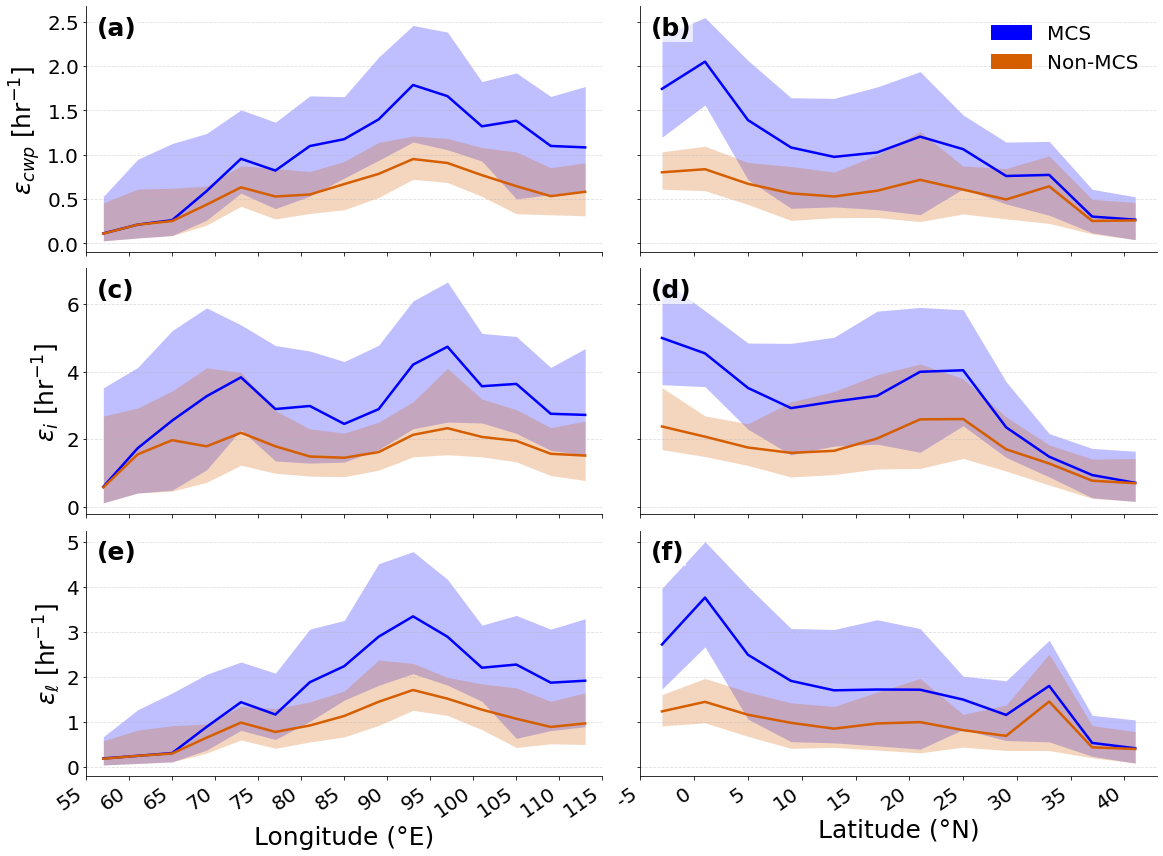

In [1]:
#!/usr/bin/env python3
"""
MAKE A 3×2 MEDIAN-LINE FIGURE (Longitude left, Latitude right) FOR THREE ε METRICS:
Row 1: ε_cwp
Row 2: ε_i
Row 3: ε_ℓ

Each panel shows:
- Solid lines: per-bin MEDIANS (MCS vs Non-MCS)
- Shading: IQR (25–75th) for each class
- Optional: prints pooled + bin-median summaries and writes per-bin CSVs (same as before)

This script reads the same NetCDF files you used for the boxplots.

Author: (your name)
"""

import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FixedLocator, FixedFormatter
import csv

# -----------------------------
# USER INPUT
# -----------------------------
files = {
    "PE": {   # ε_cwp
        "MCS": "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/MCS_PRECEFF/Obs_cwp_PRECEFF_mcs_20160809-20160909_Asia_timeavg.nc",
        "NonMCS": "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/MCS_PRECEFF/Obs_cwp_PRECEFF_non_mcs_20160809-20160909_Asia_timeavg.nc",
        "var": "PRECEFF_TIMEAVG",
        "ylabel": r"$\epsilon_{cwp}$ [hr$^{-1}$]"
    },
    "CIW": {  # ε_i
        "MCS": "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/MCS_PRECEFF/Obs_ciw_PRECEFF_mcs_20160809-20160909_Asia_timeavg.nc",
        "NonMCS": "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/MCS_PRECEFF/Obs_ciw_PRECEFF_non_mcs_20160809-20160909_Asia_timeavg.nc",
        "var": "PRECEFF_TIMEAVG",
        "ylabel": r"$\epsilon_{i}$ [hr$^{-1}$]"
    },
    "CLW": {  # ε_ℓ
        "MCS": "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/MCS_PRECEFF/Obs_clw_PRECEFF_mcs_20160809-20160909_Asia_timeavg.nc",
        "NonMCS": "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/MCS_PRECEFF/Obs_clw_PRECEFF_non_mcs_20160809-20160909_Asia_timeavg.nc",
        "var": "PRECEFF_TIMEAVG",
        "ylabel": r"$\epsilon_{\ell}$ [hr$^{-1}$]"
    }
}

# Binning controls (match your boxplot bins)
bin_width = 4.0
LON_MIN, LON_MAX = 55.0, 115.0
LAT_MIN, LAT_MAX = -5.0, 43.0

# Plot styling
COLOR_MCS_LINE = "blue"
COLOR_NON_LINE = "#D55E00"
ALPHA_IQR = 0.25

legend_fontsize = 20
tick_fontsize = 20
label_fontsize = 25
panel_label_fontsize = 25

# Output
outdir = "/xdisk/sylvia/temakgoale/MCS_TRACKS_DATA/MCS_Paper_Plots/"
os.makedirs(outdir, exist_ok=True)

out_png = os.path.join(outdir, "Figure_MedianLines_MCS_vs_NonMCS_longitude_latitude.png")
out_pdf = os.path.join(outdir, "Figure_MedianLines_MCS_vs_NonMCS_longitude_latitude.pdf")

# Optional: save stats tables
SAVE_TABLES = True
out_stats_dir = os.path.join(outdir, "MedianLine_stats_tables/")
if SAVE_TABLES:
    os.makedirs(out_stats_dir, exist_ok=True)

# Optional: print summaries
PRINT_SUMMARIES = True


# -----------------------------
# HELPERS
# -----------------------------
def _scale_to_per_hour(values, units_str):
    """Return values scaled to hr^-1 and a flag indicating scaling."""
    units = (units_str or "").strip().lower()
    if ("s-1" in units) or (units in {"1/s", "s^-1", "sec^-1", "per second"}):
        return values * 3600.0, True
    if ("h-1" in units) or (units in {"1/h", "hr^-1", "hour^-1", "per hour"}):
        return values, False
    # Heuristic if units missing
    med = np.nanmedian(values) if values.size else np.nan
    if np.isfinite(med) and (1e-6 <= med <= 1e-2):
        return values * 3600.0, True
    return values, False

def load_field(path, var):
    """Open dataset, standardize coords, convert ε to hr^-1."""
    ds = xr.open_dataset(path)
    da = ds[var]
    if "lat" not in da.coords and "latitude" in da.coords:
        da = da.rename({"latitude": "lat"})
    if "lon" not in da.coords and "longitude" in da.coords:
        da = da.rename({"longitude": "lon"})

    vals = da.values
    vals_hr, _ = _scale_to_per_hour(vals, da.attrs.get("units", ""))
    da_hr = xr.DataArray(vals_hr, coords=da.coords, dims=da.dims, attrs=da.attrs)
    da_hr.attrs["units"] = "hr^-1"

    lat = da_hr["lat"].values
    lon = da_hr["lon"].values

    ds.close()
    return da_hr, lat, lon

def normalize_lon_inplace(da_mcs, da_non):
    """Wrap lon if needed to [0,360)."""
    lon = da_mcs["lon"].values
    if (lon.min() < 0) or (lon.max() > 180):
        lon = np.mod(lon, 360.0)
        da_mcs = da_mcs.assign_coords(lon=lon)
        da_non = da_non.assign_coords(lon=lon)
    return da_mcs, da_non, lon

def make_bins(start, stop, width):
    edges = np.arange(start, stop + width, width)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return edges, centers

def collect_by_bins(da2d, coord_vals, edges, dim_name):
    """
    Collect values for each bin by selecting indices along dim_name (lat or lon),
    then flattening remaining dims.
    """
    out = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (coord_vals >= lo) & (coord_vals < hi)
        if not np.any(mask):
            out.append(np.array([]))
            continue
        idx = np.where(mask)[0]
        vals = da2d.isel({dim_name: idx}).values.ravel()
        vals = vals[np.isfinite(vals)]
        out.append(vals)
    return out

def summarize_bins(bins):
    """List of dicts with median and IQR, plus N."""
    stats = []
    for v in bins:
        if len(v) == 0:
            stats.append(dict(N=0, median=np.nan, p25=np.nan, p75=np.nan))
        else:
            stats.append(dict(
                N=int(len(v)),
                median=float(np.nanmedian(v)),
                p25=float(np.nanpercentile(v, 25)),
                p75=float(np.nanpercentile(v, 75)),
            ))
    return stats

def pooled_stats(bins):
    """Grid-cell weighted pooled distribution stats."""
    pooled_list = [v for v in bins if len(v) > 0]
    if len(pooled_list) == 0:
        return dict(N=0, median=np.nan, p25=np.nan, p75=np.nan)
    pooled = np.concatenate(pooled_list)
    pooled = pooled[np.isfinite(pooled)]
    if pooled.size == 0:
        return dict(N=0, median=np.nan, p25=np.nan, p75=np.nan)
    return dict(
        N=int(pooled.size),
        median=float(np.nanmedian(pooled)),
        p25=float(np.nanpercentile(pooled, 25)),
        p75=float(np.nanpercentile(pooled, 75)),
    )

def summarize_bin_medians(stats_list):
    """Equal-weight bin summary using bin medians."""
    meds = np.array([s["median"] for s in stats_list if np.isfinite(s["median"]) and s["N"] > 0])
    if meds.size == 0:
        return dict(Nbins=0, median=np.nan, p25=np.nan, p75=np.nan)
    return dict(
        Nbins=int(meds.size),
        median=float(np.nanmedian(meds)),
        p25=float(np.nanpercentile(meds, 25)),
        p75=float(np.nanpercentile(meds, 75)),
    )

def safe_ratio(a, b):
    if not np.isfinite(a) or not np.isfinite(b) or b == 0:
        return np.nan
    return a / b

def extract_arrays(stats):
    """Convert list-of-dicts to arrays for plotting."""
    med = np.array([s["median"] for s in stats], dtype=float)
    p25 = np.array([s["p25"] for s in stats], dtype=float)
    p75 = np.array([s["p75"] for s in stats], dtype=float)
    N = np.array([s["N"] for s in stats], dtype=int)
    return med, p25, p75, N

def write_perbin_csv(csv_path, centers, stats_mcs, stats_non, coord_name, var_label):
    header = [
        f"{coord_name}_center",
        "MCS_N", "MCS_median", "MCS_p25", "MCS_p75",
        "NonMCS_N", "NonMCS_median", "NonMCS_p25", "NonMCS_p75",
        "Delta_median(MCS-NonMCS)", "Ratio_median(MCS/NonMCS)"
    ]
    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow([f"# Per-bin medians/IQR for {var_label} along {coord_name}"])
        w.writerow(header)
        for c, sm, sn in zip(centers, stats_mcs, stats_non):
            delta = sm["median"] - sn["median"] if (sm["N"] > 0 and sn["N"] > 0) else np.nan
            ratio = safe_ratio(sm["median"], sn["median"]) if (sm["N"] > 0 and sn["N"] > 0) else np.nan
            w.writerow([
                float(c),
                sm["N"], sm["median"], sm["p25"], sm["p75"],
                sn["N"], sn["median"], sn["p25"], sn["p75"],
                delta, ratio
            ])


# -----------------------------
# BUILD THE 3×2 MEDIAN-LINE FIGURE
# -----------------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharey="row")

panel_labels = [r"(a)", r"(b)", r"(c)", r"(d)", r"(e)", r"(f)"]
pidx = 0

# Legend handles (shared)
mcs_handle = mpatches.Patch(facecolor=COLOR_MCS_LINE, edgecolor=COLOR_MCS_LINE, label="MCS")
non_handle = mpatches.Patch(facecolor=COLOR_NON_LINE, edgecolor=COLOR_NON_LINE, label="Non-MCS")

for row, (key, info) in enumerate(files.items()):
    # Load
    da_mcs, lat, lon = load_field(info["MCS"], info["var"])
    da_non, _, _     = load_field(info["NonMCS"], info["var"])
    da_mcs, da_non, lon = normalize_lon_inplace(da_mcs, da_non)

    # Make bins
    edges_lon, centers_lon = make_bins(LON_MIN, LON_MAX, bin_width)
    edges_lat, centers_lat = make_bins(LAT_MIN, LAT_MAX, bin_width)

    # Collect values in bins
    bins_mcs_lon = collect_by_bins(da_mcs, lon, edges_lon, dim_name="lon")
    bins_non_lon = collect_by_bins(da_non, lon, edges_lon, dim_name="lon")
    bins_mcs_lat = collect_by_bins(da_mcs, lat, edges_lat, dim_name="lat")
    bins_non_lat = collect_by_bins(da_non, lat, edges_lat, dim_name="lat")

    # Summarize (median + IQR)
    stats_mcs_lon = summarize_bins(bins_mcs_lon)
    stats_non_lon = summarize_bins(bins_non_lon)
    stats_mcs_lat = summarize_bins(bins_mcs_lat)
    stats_non_lat = summarize_bins(bins_non_lat)

    # Arrays for plotting
    m_med_lon, m_p25_lon, m_p75_lon, mN_lon = extract_arrays(stats_mcs_lon)
    n_med_lon, n_p25_lon, n_p75_lon, nN_lon = extract_arrays(stats_non_lon)

    m_med_lat, m_p25_lat, m_p75_lat, mN_lat = extract_arrays(stats_mcs_lat)
    n_med_lat, n_p25_lat, n_p75_lat, nN_lat = extract_arrays(stats_non_lat)

    # -------------------------
    # LEFT COLUMN: LONGITUDE LINES
    # -------------------------
    axL = axes[row, 0]

    axL.plot(centers_lon, m_med_lon, lw=2.5, color=COLOR_MCS_LINE, label="MCS" if row == 0 else None)
    axL.plot(centers_lon, n_med_lon, lw=2.5, color=COLOR_NON_LINE, label="Non-MCS" if row == 0 else None)

    axL.fill_between(centers_lon, m_p25_lon, m_p75_lon, color=COLOR_MCS_LINE, alpha=ALPHA_IQR, linewidth=0)
    axL.fill_between(centers_lon, n_p25_lon, n_p75_lon, color=COLOR_NON_LINE, alpha=ALPHA_IQR, linewidth=0)

    axL.set_xlim(LON_MIN, LON_MAX)
    tick_vals_lon = np.arange(LON_MIN, LON_MAX + 1e-6, 5.0)
    axL.xaxis.set_major_locator(FixedLocator(tick_vals_lon))
    axL.xaxis.set_major_formatter(FixedFormatter([f"{t:.0f}" for t in tick_vals_lon]))
    axL.grid(True, axis="y", linestyle="--", alpha=0.4)
    axL.set_ylabel(info["ylabel"], fontsize=label_fontsize)

    if row == 2:
        axL.set_xlabel("Longitude (°E)", fontsize=label_fontsize)

    axL.text(
        0.02, 0.96, panel_labels[pidx],
        transform=axL.transAxes, ha="left", va="top",
        fontsize=panel_label_fontsize, fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2)
    )
    pidx += 1

    # -------------------------
    # RIGHT COLUMN: LATITUDE LINES
    # -------------------------
    axR = axes[row, 1]

    axR.plot(centers_lat, m_med_lat, lw=2.5, color=COLOR_MCS_LINE)
    axR.plot(centers_lat, n_med_lat, lw=2.5, color=COLOR_NON_LINE)

    axR.fill_between(centers_lat, m_p25_lat, m_p75_lat, color=COLOR_MCS_LINE, alpha=ALPHA_IQR, linewidth=0)
    axR.fill_between(centers_lat, n_p25_lat, n_p75_lat, color=COLOR_NON_LINE, alpha=ALPHA_IQR, linewidth=0)

    axR.set_xlim(LAT_MIN, LAT_MAX)
    tick_vals_lat = np.arange(LAT_MIN, LAT_MAX + 1e-6, 5.0)
    axR.xaxis.set_major_locator(FixedLocator(tick_vals_lat))
    axR.xaxis.set_major_formatter(FixedFormatter([f"{t:.0f}" for t in tick_vals_lat]))
    axR.grid(True, axis="y", linestyle="--", alpha=0.4)

    if row == 2:
        axR.set_xlabel("Latitude (°N)", fontsize=label_fontsize)

    axR.text(
        0.02, 0.96, panel_labels[pidx],
        transform=axR.transAxes, ha="left", va="top",
        fontsize=panel_label_fontsize, fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2)
    )
    pidx += 1

    # -------------------------
    # OPTIONAL: PRINT SUMMARIES
    # -------------------------
    if PRINT_SUMMARIES:
        pooled_mcs = pooled_stats(bins_mcs_lon)   # same as pooled lat
        pooled_non = pooled_stats(bins_non_lon)

        bm_mcs_lon = summarize_bin_medians(stats_mcs_lon)
        bm_non_lon = summarize_bin_medians(stats_non_lon)
        bm_mcs_lat = summarize_bin_medians(stats_mcs_lat)
        bm_non_lat = summarize_bin_medians(stats_non_lat)

        print("\n" + "=" * 100)
        print(f"{key} :: {info['ylabel']}")
        print("-" * 100)
        print("DOMAIN-WIDE (all grid cells pooled; independent of lon/lat binning)")
        print(f"  MCS     : median={pooled_mcs['median']:.3f}, IQR={pooled_mcs['p25']:.3f}–{pooled_mcs['p75']:.3f}, N={pooled_mcs['N']}")
        print(f"  Non-MCS : median={pooled_non['median']:.3f}, IQR={pooled_non['p25']:.3f}–{pooled_non['p75']:.3f}, N={pooled_non['N']}")
        print(f"  Δmedian = {(pooled_mcs['median'] - pooled_non['median']):.3f}")
        print(f"  Ratio   = {safe_ratio(pooled_mcs['median'], pooled_non['median']):.3f}")

        print("\nBIN-AVERAGED (equal weight per longitude bin; using bin medians)")
        print(f"  MCS     : median={bm_mcs_lon['median']:.3f}, IQR={bm_mcs_lon['p25']:.3f}–{bm_mcs_lon['p75']:.3f}, Nbins={bm_mcs_lon['Nbins']}")
        print(f"  Non-MCS : median={bm_non_lon['median']:.3f}, IQR={bm_non_lon['p25']:.3f}–{bm_non_lon['p75']:.3f}, Nbins={bm_non_lon['Nbins']}")
        print(f"  Δmedian = {(bm_mcs_lon['median'] - bm_non_lon['median']):.3f}")
        print(f"  Ratio   = {safe_ratio(bm_mcs_lon['median'], bm_non_lon['median']):.3f}")

        print("\nBIN-AVERAGED (equal weight per latitude bin; using bin medians)")
        print(f"  MCS     : median={bm_mcs_lat['median']:.3f}, IQR={bm_mcs_lat['p25']:.3f}–{bm_mcs_lat['p75']:.3f}, Nbins={bm_mcs_lat['Nbins']}")
        print(f"  Non-MCS : median={bm_non_lat['median']:.3f}, IQR={bm_non_lat['p25']:.3f}–{bm_non_lat['p75']:.3f}, Nbins={bm_non_lat['Nbins']}")
        print(f"  Δmedian = {(bm_mcs_lat['median'] - bm_non_lat['median']):.3f}")
        print(f"  Ratio   = {safe_ratio(bm_mcs_lat['median'], bm_non_lat['median']):.3f}")

    # -------------------------
    # OPTIONAL: SAVE TABLES
    # -------------------------
    if SAVE_TABLES:
        csv_lon = os.path.join(out_stats_dir, f"medianline_{key}_longitude.csv")
        csv_lat = os.path.join(out_stats_dir, f"medianline_{key}_latitude.csv")
        write_perbin_csv(csv_lon, centers_lon, stats_mcs_lon, stats_non_lon, "lon", info["ylabel"])
        write_perbin_csv(csv_lat, centers_lat, stats_mcs_lat, stats_non_lat, "lat", info["ylabel"])

# -------------------------
# LEGEND ONCE
# -------------------------
axes[0, 1].legend(handles=[mcs_handle, non_handle], loc="upper right", frameon=False, fontsize=legend_fontsize)

# -------------------------
# AXIS COSMETICS
# -------------------------
for ax in axes.ravel():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")
    ax.tick_params(axis="x", labelsize=tick_fontsize)
    ax.tick_params(axis="y", labelsize=tick_fontsize)

# Hide x tick labels for top two rows
for r in range(2):
    for c in range(2):
        axes[r, c].tick_params(labelbottom=False)

# Rotate bottom row ticks
for c in range(2):
    plt.setp(axes[2, c].get_xticklabels(), rotation=35, ha="right")

plt.tight_layout()

# Save
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.savefig(out_pdf, dpi=50, bbox_inches="tight")

print("\nSaved median-line figure:")
print(f"  PNG: {out_png}")
print(f"  PDF: {out_pdf}")
if SAVE_TABLES:
    print("\nSaved per-bin median/IQR tables to:")
    print(f"  {out_stats_dir}")
print("\nDone.")
